##Maximum Likelihood Estimation (MLE) of Binomial Distribution


# Aim

To estimate the probability parameter **p** of a Binomial distribution using the **Maximum Likelihood Estimation (MLE)** method on the Breast Cancer Wisconsin dataset.

---

# Introduction

Maximum Likelihood Estimation (MLE) is a statistical method used to estimate the unknown parameters of a probability distribution by finding the values that make the observed data most likely.

In this experiment:

- **Malignant (0)** is considered a **success**.
- **Benign (1)** is considered a **failure**.

Since the Binomial distribution models the number of successes in a fixed number of independent trials, the dataset is divided into **non-overlapping batches of 10 patients**.

Each batch is treated as one Binomial experiment, where the number of malignant cases represents the number of successes.

The probability parameter **p** is estimated using two approaches:

1. **Grid Search** – Evaluates the log-likelihood for different values of **p** and selects the value with the highest likelihood.
2. **Analytical MLE** – Computes **p** directly using the Maximum Likelihood Estimation formula.

Finally, the **log-likelihood curve** is plotted to visualize how the likelihood changes with different values of **p** and to identify the estimated MLE.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb
from sklearn.datasets import load_breast_cancer


#Load Dataset

In [ ]:
data= load_breast_cancer()
target = data.target

bernoulli=(target==0).astype(int)

#Make batches

In [7]:
batch_size =10

num_batches = len(bernoulli)//batch_size

bernoulli=bernoulli[:num_batches * batch_size]

batches= bernoulli.reshape(num_batches,batch_size)

successes=batches.sum(axis=1)

print("Number of Batches: ",num_batches)
print("Number of Successes:\n ")

print(successes)

Number of Batches:  56
Number of Successes:
 
[10  9  8  9  7  4  3  6  5  4  3  3  5  5  2  1  5  3  5  7  5  7  2  5
  1  9  6  3  3  1  2  1  4  4  1  3  4  4  2  2  2  2  0  4  4  1  3  1
  2  3  3  4  1  3  0  0]


#Total Successes

In [8]:
total_successes=sum(successes)
total_trials= num_batches * batch_size

print("\n Total Success: ",total_successes)
print("Total trials: ",total_trials)


 Total Success:  206
Total trials:  560


#Binomial Likelyhood

In [9]:
def likelihood(p, observations, n):

    L = 1

    for x in observations:

        L *= comb(n, x) * (p**x) * ((1-p)**(n-x))

    return L

#Log Likelihood


In [10]:
def log_likelihood(p, observations, n):

    ll = 0

    for x in observations:

        ll += np.log(comb(n, x))

        ll += x*np.log(p)

        ll += (n-x)*np.log(1-p)

    return ll

#Grid Search


In [11]:
p_values = np.linspace(0.05,0.95,200)

log_values = []

for p in p_values:

    log_values.append(log_likelihood(p,successes,batch_size))

best_index = np.argmax(log_values)

grid_p = p_values[best_index]

print("\nGrid Search Estimate =",grid_p)


Grid Search Estimate = 0.3665829145728643


#Analytical MLE

In [12]:
mle = total_successes / total_trials

print("Analytical MLE =",mle)


Analytical MLE = 0.3678571428571429


#Plots

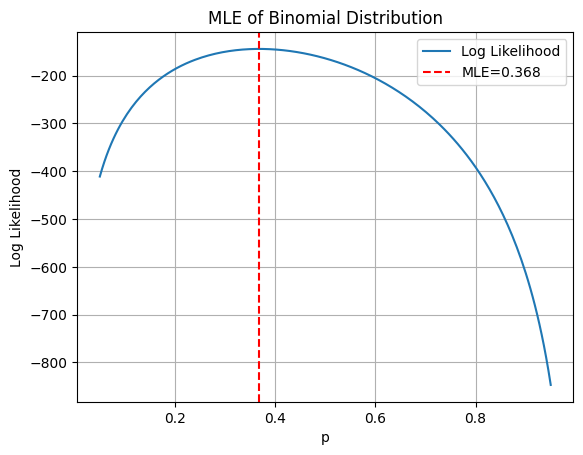

In [13]:

plt.plot(p_values,log_values,label="Log Likelihood")

plt.axvline(mle,color='red',linestyle='--',label=f"MLE={mle:.3f}")

plt.xlabel("p")

plt.ylabel("Log Likelihood")

plt.title("MLE of Binomial Distribution")

plt.legend()

plt.grid(True)

plt.show()

## Conclusion

> Estimated the parameter **p** of a Binomial distribution using the MLE method.
>
> Compared the **grid search** and **analytical** estimates, which produced nearly identical results.
>
> Plotted the **log-likelihood curve** to identify the optimal value of **p**.
>
> Verified the effectiveness of MLE for estimating unknown parameters from observed data.